In [ ]:
# import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Heart Disease Classification Analysis

This notebook analyzes a heart disease dataset using multiple machine learning classification models. The workflow includes data exploration, visualization, preprocessing, dimensionality reduction using PCA, class balancing with SMOTE, model training, cross validation, and evaluation. 

The goal of this analysis is to compare the performance of multiple classification algorithms and evaluate how preprocessing techniques such as PCA and SMOTE affect prediction performance.

In [ ]:
# load the diabetes dataset
df = pd.read_csv('data/heart.csv')

In [ ]:
df.head() # display first five

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
df.shape # display dimensions

(1025, 14)

In [ ]:
df.info() # display dataset info and data types

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [ ]:
# generate summary stats for numerical deatures
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
# check for missing values
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [ ]:
df['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

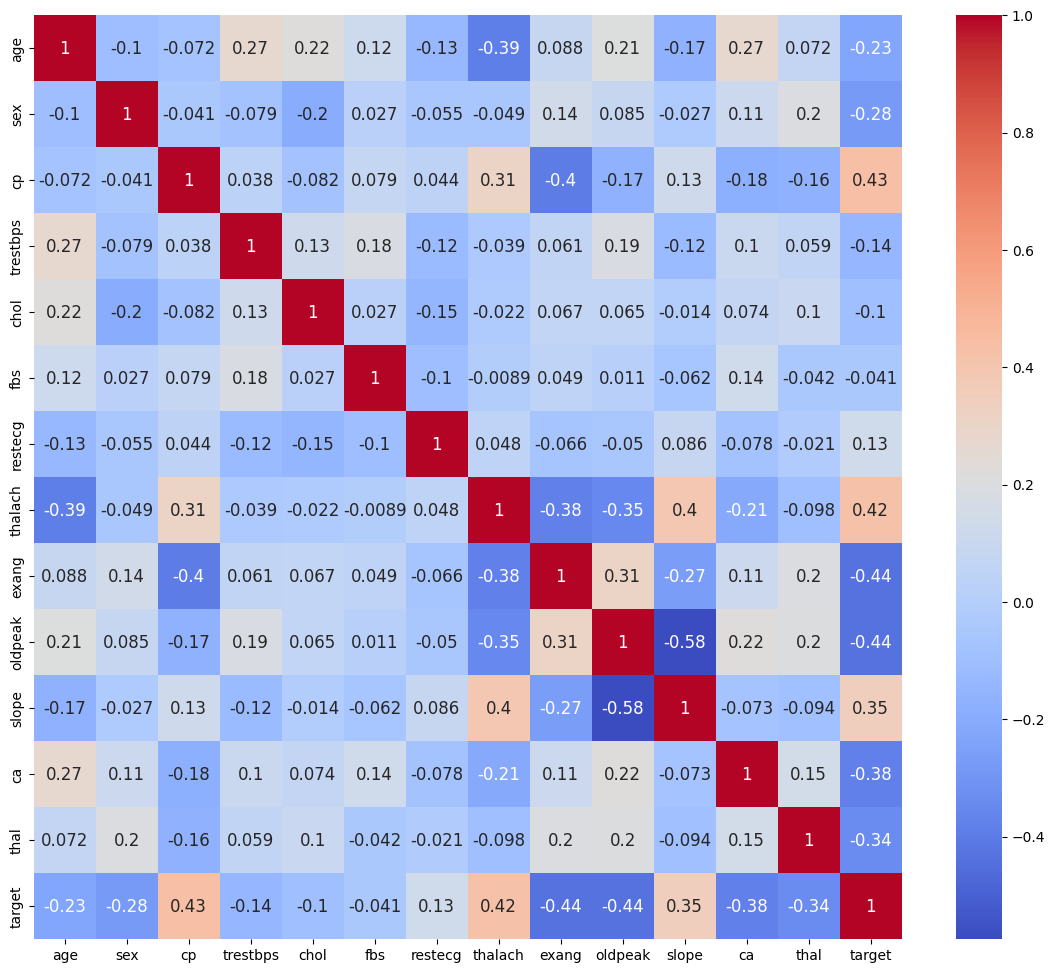

In [ ]:
# create correlation heatmap for feature relationships
plt.figure(figsize=(14, 12))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    annot_kws={"size": 12}
)

plt.show()

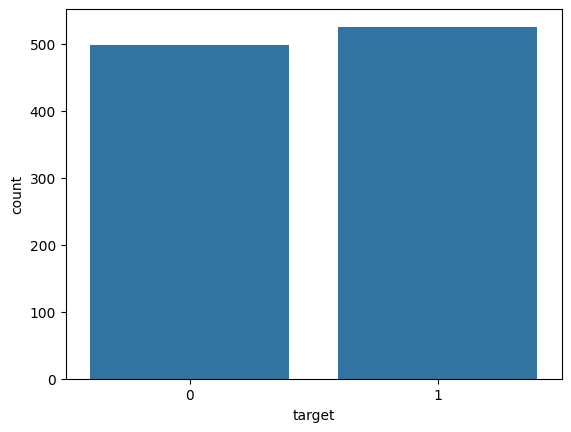

In [ ]:
# visualize class distribution
sns.countplot(x='target', data=df)
plt.show()

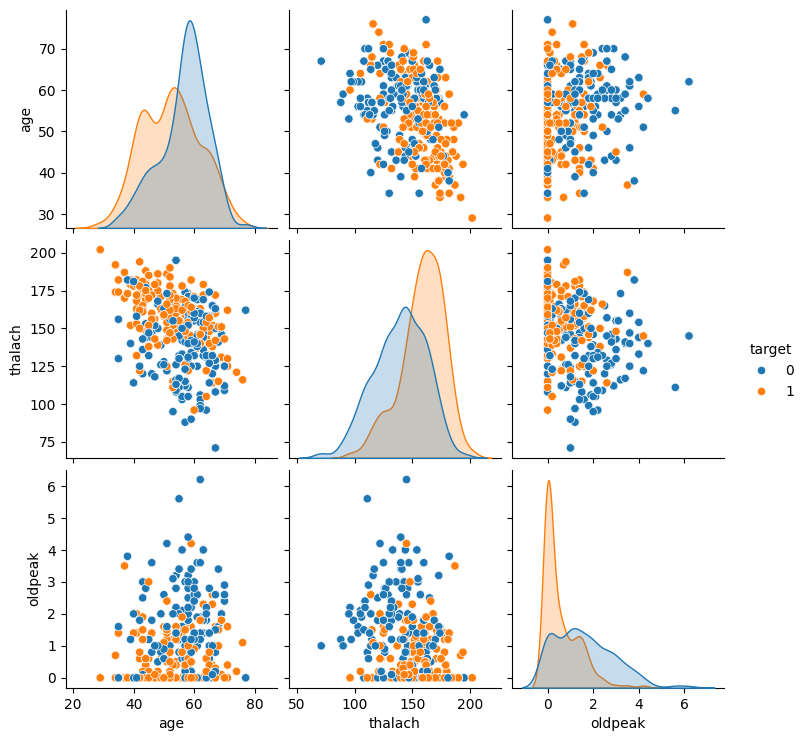

In [ ]:
# create pairplot for selected features
sns.pairplot(
    df[['age', 'thalach', 'oldpeak', 'target']],
    hue='target'
)

plt.show()

In [ ]:
# create a copy of the dataset for preprocessing
df_clean = df.copy()

In [ ]:
# separate features and target variable
X = df_clean.drop('target', axis=1)
y = df_clean['target']

In [ ]:
# standardize feature values using StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# apply PCA for dimensionality reduction
pca = PCA(n_components=5)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [ ]:
# display explained variance ratio for PCA components
print(pca.explained_variance_ratio_)

[0.21785019 0.1216509  0.09231635 0.09082073 0.07469387]


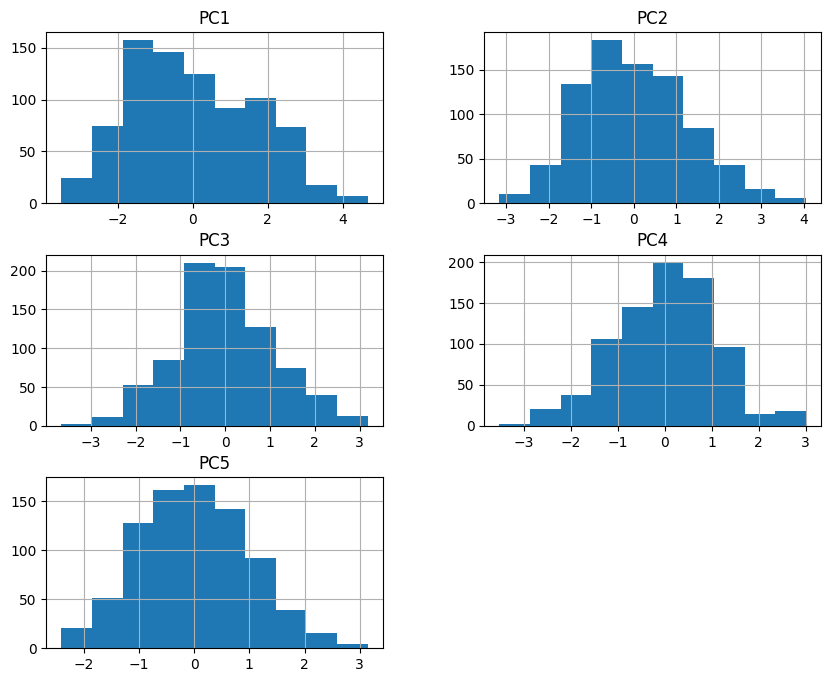

In [20]:
pca_df = pd.DataFrame(
    X_train_pca,
    columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5']
)

pca_df.hist(figsize=(10,8))
plt.show()

This dataset was already relatively balanced between positive and negative cases, but SMOTE was still applied to follow the required project pipeline.

In [ ]:
# apply SMOTE to balance training classes
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_pca,
    y_train
)

In [ ]:
# display class counts before and after SMOTE
print("====Before SMOTE:====")
print(pd.Series(y_train).value_counts())

print()

print("====After SMOTE:====")
print(pd.Series(y_train_smote).value_counts())

====Before SMOTE:====
target
1    421
0    399
Name: count, dtype: int64

====After SMOTE:====
target
0    421
1    421
Name: count, dtype: int64


In [23]:
knn = KNeighborsClassifier(n_neighbors=5)

In [ ]:
# train and evaluate KNN model
knn.fit(X_train_smote, y_train_smote)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [25]:
y_pred_knn = knn.predict(X_test_pca)

In [26]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.89      0.81      0.85       100
           1       0.83      0.90      0.87       105

    accuracy                           0.86       205
   macro avg       0.86      0.86      0.86       205
weighted avg       0.86      0.86      0.86       205



In [ ]:
# generate confusion matrix for KNN model
cm_knn = confusion_matrix(y_test, y_pred_knn)

print(cm_knn)

[[81 19]
 [10 95]]


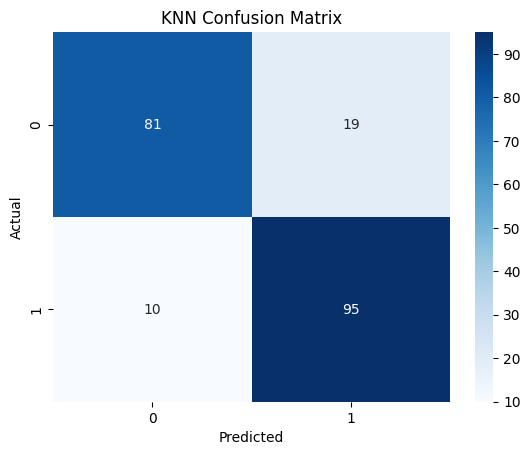

In [28]:
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN Confusion Matrix')

plt.show()

In [ ]:
# perform cross validation for KNN model
knn_f1_scores = cross_val_score(
    knn,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring='f1'
)

print(knn_f1_scores)
print(knn_f1_scores.mean())
print(knn_f1_scores.std())

[0.87719298 0.85207101 0.86419753 0.83950617 0.8125    ]
0.8490935384154007
0.022170156916274872


In [30]:
gnb = GaussianNB()

In [ ]:
# train and evaluate Gaussian Naive Bayes model
gnb.fit(X_train_smote, y_train_smote)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [32]:
y_pred_gnb = gnb.predict(X_test_pca)

In [33]:
print(classification_report(y_test, y_pred_gnb))

              precision    recall  f1-score   support

           0       0.86      0.67      0.75       100
           1       0.74      0.90      0.81       105

    accuracy                           0.79       205
   macro avg       0.80      0.78      0.78       205
weighted avg       0.80      0.79      0.78       205



In [34]:
cm_gnb = confusion_matrix(y_test, y_pred_gnb)

print(cm_gnb)

[[67 33]
 [11 94]]


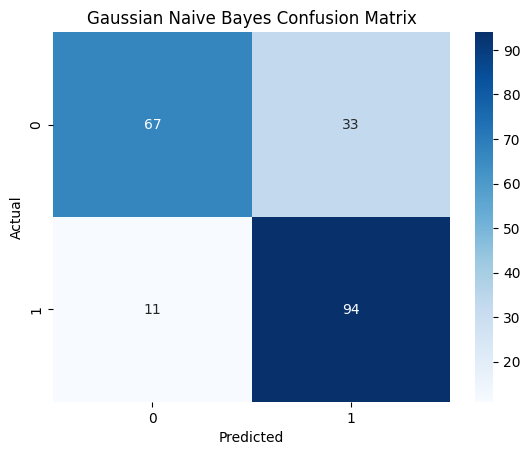

In [35]:
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Gaussian Naive Bayes Confusion Matrix')

plt.show()

In [36]:
gnb_f1_scores = cross_val_score(
    gnb,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring='f1'
)

print(gnb_f1_scores)
print(gnb_f1_scores.mean())
print(gnb_f1_scores.std())

[0.83870968 0.85393258 0.81142857 0.83977901 0.77714286]
0.8241985391570615
0.027257097388652236


In [37]:
log_reg = LogisticRegression(max_iter=1000)

In [ ]:
# train and evaluate Logistic Regression model
log_reg.fit(X_train_smote, y_train_smote)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [39]:
y_pred_log = log_reg.predict(X_test_pca)

In [40]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.89      0.77      0.82       100
           1       0.81      0.90      0.85       105

    accuracy                           0.84       205
   macro avg       0.85      0.84      0.84       205
weighted avg       0.84      0.84      0.84       205



In [41]:
cm_log = confusion_matrix(y_test, y_pred_log)

print(cm_log)

[[77 23]
 [10 95]]


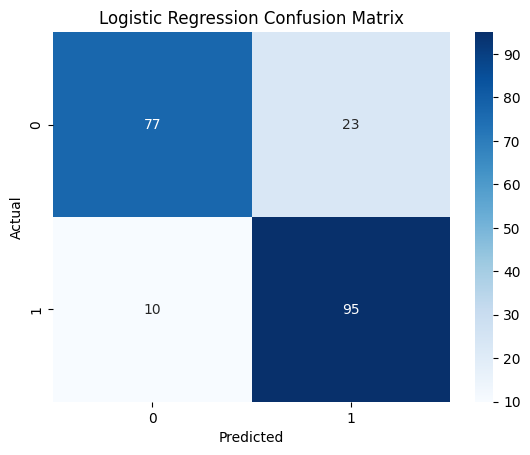

In [42]:
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')

plt.show()

In [43]:
log_f1_scores = cross_val_score(
    log_reg,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring='f1'
)

print(log_f1_scores)
print(log_f1_scores.mean())
print(log_f1_scores.std())

[0.87431694 0.81927711 0.85057471 0.85393258 0.82080925]
0.8437821187585399
0.021022820361531087


In [44]:
dt = DecisionTreeClassifier(random_state=42)

In [ ]:
# train and evaluate Decision Tree model
dt.fit(X_train_smote, y_train_smote)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [46]:
y_pred_dt = dt.predict(X_test_pca)

In [47]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



In [48]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)

[[100   0]
 [  0 105]]


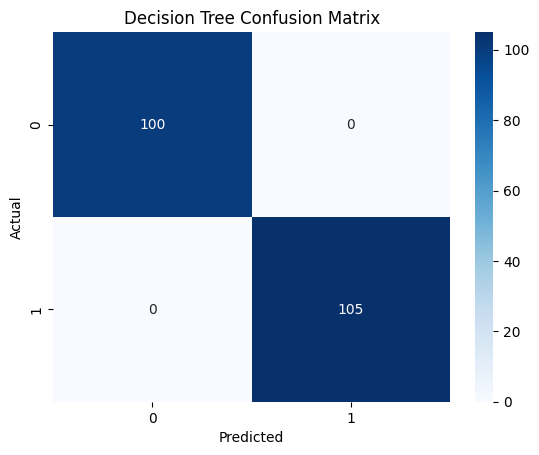

In [49]:
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix')

plt.show()

In [50]:
dt_f1_scores = cross_val_score(
    dt,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring='f1'
)

print(dt_f1_scores)
print(dt_f1_scores.mean())
print(dt_f1_scores.std())

[0.95857988 0.98245614 0.99408284 0.96932515 0.98823529]
0.9785358619472497
0.012916922256419846


In [51]:
svm = SVC()

In [ ]:
# train and evaluate SVM model
svm.fit(X_train_smote, y_train_smote)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [53]:
y_pred_svm = svm.predict(X_test_pca)

In [54]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.87      0.79      0.83       100
           1       0.82      0.89      0.85       105

    accuracy                           0.84       205
   macro avg       0.84      0.84      0.84       205
weighted avg       0.84      0.84      0.84       205



In [55]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

print(cm_svm)

[[79 21]
 [12 93]]


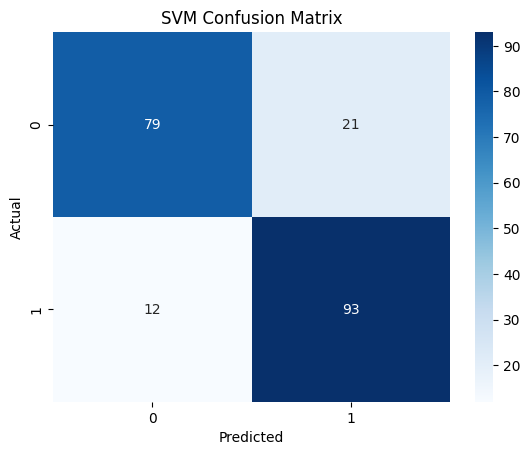

In [56]:
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix')

plt.show()

In [57]:
svm_f1_scores = cross_val_score(
    svm,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring='f1'
)

print(svm_f1_scores)
print(svm_f1_scores.mean())
print(svm_f1_scores.std())

[0.87431694 0.85714286 0.85380117 0.85057471 0.82716049]
0.8525992346190099
0.01513258799998993


In [ ]:
# compare overall model performance using F1 scores
results = pd.DataFrame({
    'Model': [
        'KNN',
        'Gaussian Naive Bayes',
        'Logistic Regression',
        'Decision Tree',
        'SVM'
    ],

    'Mean F1 Score': [
        knn_f1_scores.mean(),
        gnb_f1_scores.mean(),
        log_f1_scores.mean(),
        dt_f1_scores.mean(),
        svm_f1_scores.mean()
    ],

    'F1 Std Dev': [
        knn_f1_scores.std(),
        gnb_f1_scores.std(),
        log_f1_scores.std(),
        dt_f1_scores.std(),
        svm_f1_scores.std()
    ]
})

results

,Model,Mean F1 Score,F1 Std Dev
0,KNN,0.849094,0.022170
1,Gaussian Naive Bayes,0.824199,0.027257
2,Logistic Regression,0.843782,0.021023
3,Decision Tree,0.978536,0.012917
4,SVM,0.852599,0.015133


# Results Discussion

## Which model performed best and why?

The Decision Tree model performed the best overall on the heart disease dataset. Its confusion matrix showed perfect classification performance with 100 true negatives and 105 true positives, with no false positives or false negatives. This indicates that the model classified every test sample correctly. Logistic Regression, KNN, and SVM also performed very well, but Decision Tree achieved the strongest overall performance.

## Which model performed worst?

Gaussian Naive Bayes performed the weakest overall compared to the other models. Although it still classified many cases correctly, it produced more false positives than the other models. Its confusion matrix showed lower overall accuracy and weaker balance compared to Logistic Regression, KNN, and Decision Tree.

## How did SMOTE help with class imbalance?

SMOTE balanced the training dataset by generating synthetic samples for the minority class. However, unlike the diabetes dataset, the heart disease dataset was already relatively balanced before SMOTE was applied. Because of this, SMOTE likely had a smaller impact on model performance compared to the diabetes dataset.

## Did cross validation agree with test set performance?

Yes, the cross validation scores were generally consistent with the test set results. Models that performed well on the test set also tended to have strong F1 scores during cross validation. This suggests that the models generalized well and were not heavily overfitting the training data.

## How did PCA affect the dataset?

PCA reduced the dimensionality of the dataset to five principal components while still preserving important information from the original features. This simplified the feature space, reduced redundancy between correlated variables, and improved computational efficiency for the machine learning models.

## Compare the diabetes and heart datasets

The heart disease dataset was easier for the models to classify than the diabetes dataset. Most models achieved stronger classification performance on the heart dataset, especially the Decision Tree model. The diabetes dataset was more imbalanced and contained more difficult classification patterns, making prediction more challenging overall. Additionally, SMOTE appeared to be more useful for the diabetes dataset because its classes were less balanced than the heart dataset.

## Which metrics were most important for evaluating performance?

The most important metrics were the F1 score, precision, recall, and confusion matrices. F1 score was especially important because it balances precision and recall into a single metric. Recall was also critical because it measured how well the models identified patients with heart disease, while precision measured how accurate the positive predictions were.